In [1]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [2]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

# Qiskit Aer
Qiskit Aer is a simulator with noise handling capabilities.
## Core functionalities
* Ideal simulation
* Noise simulation
* Performance optimization upto 30 qubits

In [4]:
import numpy as np

# Import Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

## Simulating a Quantum Circuit
The basic operation runs a quantum circuit and returns a counts dictionary of measurement outcomes. Here we run a simple circuit that prepares a 2-qubit Bell-state $\frac{\ket{00} + \ket{11}}{\sqrt{2}}$ and measures both qubits.

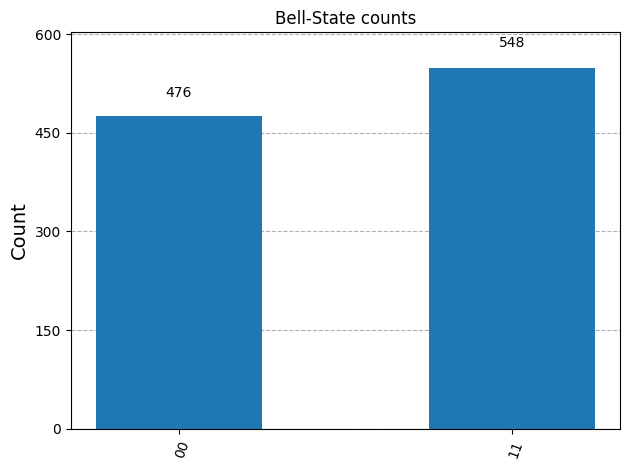

In [5]:
# Create circuit
circ = QuantumCircuit(2)
circ.h(0)
circ.cx(0, 1)
circ.measure_all()

# Transpile for simulator
simulator = AerSimulator()
circ = transpile(circ, simulator)

# Run and get counts
result = simulator.run(circ).result()
counts = result.get_counts(circ)
plot_histogram(counts, title='Bell-State counts')

## Simulation methods
* `automatic`
* `statevector`
* `density_matrix`

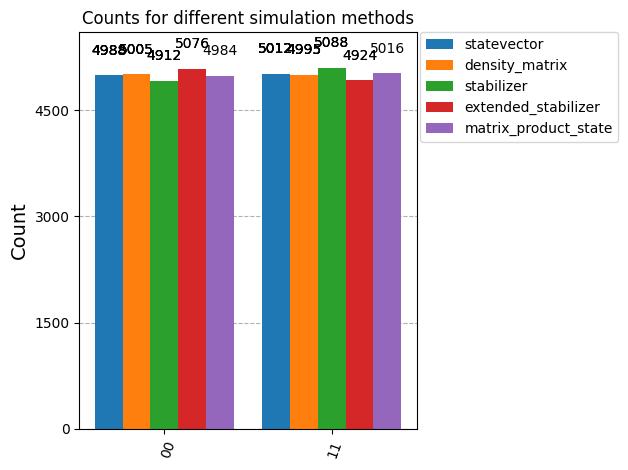

In [6]:
# Increase shots to reduce sampling variance
shots = 10000



# Statevector simulation method
sim_statevector = AerSimulator(method='statevector')
job_statevector = sim_statevector.run(circ, shots=shots)
counts_statevector = job_statevector.result().get_counts(0)

# Stabilizer simulation method
sim_stabilizer = AerSimulator(method='stabilizer')
job_stabilizer = sim_stabilizer.run(circ, shots=shots)
counts_stabilizer = job_stabilizer.result().get_counts(0)


# Extended Stabilizer method
sim_extstabilizer = AerSimulator(method='extended_stabilizer')
job_extstabilizer = sim_extstabilizer.run(circ, shots=shots)
counts_extstabilizer = job_extstabilizer.result().get_counts(0)

# Density Matrix simulation method
sim_density = AerSimulator(method='density_matrix')
job_density = sim_density.run(circ, shots=shots)
counts_density = job_density.result().get_counts(0)

# Matrix Product State simulation method
sim_mps = AerSimulator(method='matrix_product_state')
job_mps = sim_mps.run(circ, shots=shots)
counts_mps = job_mps.result().get_counts(0)


plot_histogram([ counts_statevector,counts_stabilizer ,counts_extstabilizer, counts_density, counts_mps],
               title='Counts for different simulation methods',
               legend=[ 'statevector',
                       'density_matrix','stabilizer','extended_stabilizer', 'matrix_product_state'])

## Saving Simulator state
* `save_state`
* `save_statevector`
* `save_unitary`

<IPython.core.display.Latex object>

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


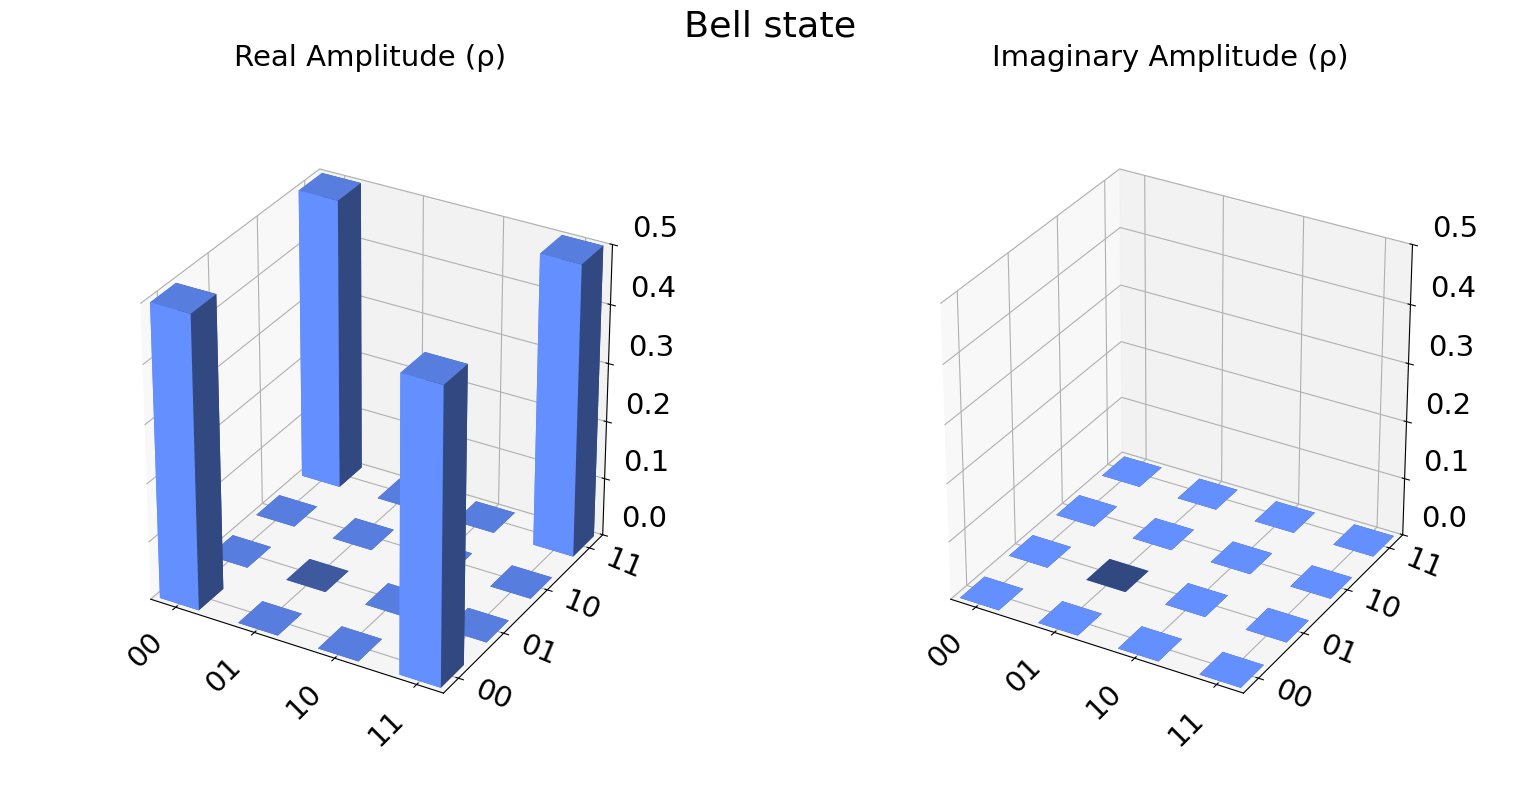

In [16]:
from qiskit.quantum_info import Statevector # quantum states
# Construct quantum circuit without measure
circ = QuantumCircuit(2)
circ.h(0)
circ.cx(0, 1)
display(Statevector(circ).draw("latex"))
circ.save_statevector()

# Transpile for simulator
simulator = AerSimulator(method='statevector')
circ = transpile(circ, simulator)

# Run and get statevector
result = simulator.run(circ).result()
statevector = result.get_statevector(circ)
print(statevector)
plot_state_city(statevector, title='Bell state')

## Setting the simulator to a custom state
* `set_statevector`
* `set_unitary`

In [20]:
# Generate a random statevector
num_qubits = 2
psi = qi.random_statevector(2 ** num_qubits, seed=100)
display(psi.draw("latex"))
# Set initial state to generated statevector
circ = QuantumCircuit(num_qubits)
circ.set_statevector(psi)
# circ.set_statevector(statevector) # --- previous saved statevector
circ.save_state()

# Transpile for simulator
simulator = AerSimulator(method='statevector')
circ = transpile(circ, simulator)

# Run and get saved data
result = simulator.run(circ).result()
result.data(0)

<IPython.core.display.Latex object>

{'statevector': Statevector([-0.49859823-0.41410205j,  0.12480824+0.46132192j,
               0.33634191+0.30214216j,  0.234309  +0.3036574j ],
             dims=(2, 2))}

# Backend

In [22]:
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2
device_backend = FakeKolkataV2()

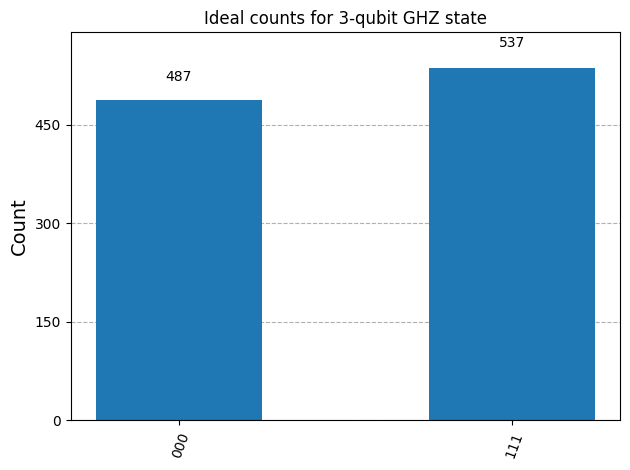

In [23]:
# Construct quantum circuit
circ = QuantumCircuit(3, 3)
circ.h(0)
circ.cx(0, 1)
circ.cx(1, 2)
circ.measure([0, 1, 2], [0, 1, 2])

sim_ideal = AerSimulator()

# Execute and get counts
result = sim_ideal.run(transpile(circ, sim_ideal)).result()
counts = result.get_counts(0)
plot_histogram(counts, title='Ideal counts for 3-qubit GHZ state')

## Backend simulation

In [24]:
sim_kolkata = AerSimulator.from_backend(device_backend)

By storing the device properties in `sim_kolkata`, we ensure that the appropriate basis gates and coupling map are used when compiling circuits for simulation, thereby most closely mimicking the gates that will be executed on a real device. In addition `sim_kolkata` contains an approximate noise model consisting of:
* Single-qubit gate errors consisting of a single qubit depolarizing error followed by a single qubit thermal relaxation error.
* Two-qubit gate errors consisting of a two-qubit depolarizing error followed by single-qubit thermal relaxation errors on both qubits in the gate.
* Single-qubit readout errors on the classical bit value obtained from measurements on individual qubits.

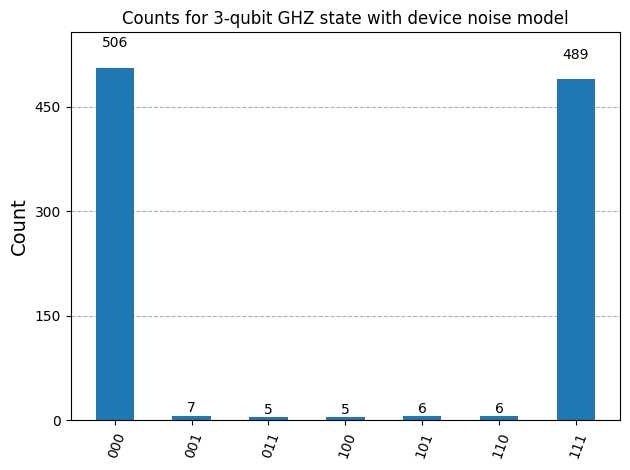

In [25]:
# Transpile the circuit for the noisy basis gates
tcirc = transpile(circ, sim_kolkata)

# Execute noisy simulation and get counts
result_noise = sim_kolkata.run(tcirc).result()
counts_noise = result_noise.get_counts(0)
plot_histogram(counts_noise,
               title="Counts for 3-qubit GHZ state with device noise model")

# Building noise models

In [37]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator

# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

## Qiskit Aer Noise module
The Qiskit Aer noise module contains Python classes to build customized noise models for simulation. There are three key classes:
1. The `NoiseModel` class which stores a noise model used for noisy simulation.
2. The `QuantumError` class which describes CPTP gate errors. These can be applied:
    * After gate or reset instructions
    * Before measure instructions.
3. The `ReadoutError` class which describes classical readout errors.

## Quantum errors
* `kraus_error` : $$\mathcal{E}(\rho) = \sum_k E_k\rho E_k^\dagger$$ such that $\sum_k E_k^\dagger E_k = I$
* `depolarising_error` : $$\mathcal{E}(\rho) = \frac{pI}{2} + (1-p)\rho = (1-p)\rho + \frac{p}{3}(X\rho X + Y\rho Y + Z\rho Z)$$
* `amplitude_damping_error` : $$\begin{aligned}E_0 &= \begin{bmatrix}1 & 0\\ 0 & \sqrt{1-\gamma}\end{bmatrix}\\ E_1 &= \begin{bmatrix}0 & \sqrt{\gamma}\\ 0 & 0\end{bmatrix}\end{aligned}$$
* `phase_damping_error` $$\begin{aligned}E_0 &= \begin{bmatrix}1 & 0\\ 0 & \sqrt{1-\lambda}\end{bmatrix}\\ E_1 &= \begin{bmatrix}0 & 0\\ 0 & \sqrt{\lambda}\end{bmatrix}\end{aligned}$$
* `phase_amplitude_damping_error` : $$\begin{aligned}E_0 &= \begin{bmatrix}1 & 0\\ 0 & \sqrt{1-\gamma-\lambda}\end{bmatrix}\\ E_1 &= \begin{bmatrix}0 & \sqrt{\gamma}\\ 0 & 0\end{bmatrix}\\ E_2 &= \begin{bmatrix}0 & 0\\ 0 & \sqrt{\lambda}\end{bmatrix}\end{aligned}$$
* `thermal_relaxation_error` : $$\begin{aligned}E_0 &= \sqrt{1 - p_1}\begin{bmatrix}1 & 0\\ 0 & 1\end{bmatrix}\\ E_1 &= \sqrt{p_1}\begin{bmatrix}0 & 1\\ 0 & 0\end{bmatrix} \\ E_2 &= \sqrt{p_z}\begin{bmatrix}1 & 0\\ 0 & -1\end{bmatrix}\end{aligned}$$

### Backend noise model

In [41]:
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2
from qiskit_aer.noise import NoiseModel

# Use a local snapshot of the Brisbane system
fake_backend = FakeKolkataV2()
noise_model = NoiseModel.from_backend(fake_backend)
print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['cx', 'sx', 'id', 'x', 'measure', 'reset']
  Qubits with noise: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
  Specific qubit errors: [('cx', (0, 1)), ('cx', (1, 0)), ('cx', (1, 2)), ('cx', (1, 4)), ('cx', (2, 1)), ('cx', (2, 3)), ('cx', (3, 2)), ('cx', (3, 5)), ('cx', (4, 1)), ('cx', (4, 7)), ('cx', (5, 3)), ('cx', (5, 8)), ('cx', (6, 7)), ('cx', (7, 4)), ('cx', (7, 6)), ('cx', (7, 10)), ('cx', (8, 5)), ('cx', (8, 9)), ('cx', (8, 11)), ('cx', (9, 8)), ('cx', (10, 7)), ('cx', (10, 12)), ('cx', (11, 8)), ('cx', (11, 14)), ('cx', (12, 10)), ('cx', (12, 13)), ('cx', (12, 15)), ('cx', (13, 12)), ('cx', (13, 14)), ('cx', (14, 11)), ('cx', (14, 13)), ('cx', (14, 16)), ('cx', (15, 12)), ('cx', (15, 18)), ('cx', (16, 14)), ('cx', (16, 19)), ('cx', (17, 18)), ('cx', (18, 15)), ('cx', (18, 17)), ('cx', (18, 21)), ('cx', (19, 16)),

In [ ]:
noise_dict = noise_model.to_dict()
display(noise_dict)

{'errors': [{'type': 'qerror',
   'id': '24afa2e16bb6407988698a22a1e7c0e2',
   'operations': ['cx'],
   'instructions': [[{'name': 'pauli', 'qubits': [0, 1], 'params': ['II']},
     {'name': 'id', 'qubits': [0]},
     {'name': 'kraus',
      'qubits': [1],
      'params': [array([[-1.        +0.j,  0.        +0.j],
              [ 0.        +0.j, -0.99818807+0.j]]),
       array([[0.        +0.j, 0.06017121+0.j],
              [0.        +0.j, 0.        +0.j]])]}],
    [{'name': 'pauli', 'qubits': [0, 1], 'params': ['II']},
     {'name': 'z', 'qubits': [0]},
     {'name': 'kraus',
      'qubits': [1],
      'params': [array([[-1.        +0.j,  0.        +0.j],
              [ 0.        +0.j, -0.99818807+0.j]]),
       array([[0.        +0.j, 0.06017121+0.j],
              [0.        +0.j, 0.        +0.j]])]}],
    [{'name': 'pauli', 'qubits': [0, 1], 'params': ['II']},
     {'name': 'reset', 'qubits': [0]},
     {'name': 'kraus',
      'qubits': [1],
      'params': [array([[-1.       

### Combining errors
`QuantumError` instances can be combined by using composition, tensor product, and tensor expansion (reversed order tensor product) to produce new QuantumErrors as:

* Composition: as `error = error1.compose(error2)`
* Tensor product: as `error = error1.tensor(error2)`
* Expand product: as `error = error1.expand(error2)`

In [27]:
# Construct a 1-qubit bit-flip and phase-flip errors
p_error = 0.05
bit_flip = pauli_error([('X', p_error), ('I', 1 - p_error)])
phase_flip = pauli_error([('Z', p_error), ('I', 1 - p_error)])
print(bit_flip)
print(phase_flip)

QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.05, Circuit = 
   ┌───┐
q: ┤ X ├
   └───┘
  P(1) = 0.95, Circuit = 
   ┌───┐
q: ┤ I ├
   └───┘
QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.05, Circuit = 
   ┌───┐
q: ┤ Z ├
   └───┘
  P(1) = 0.95, Circuit = 
   ┌───┐
q: ┤ I ├
   └───┘


In [28]:
# Compose two bit-flip and phase-flip errors
bitphase_flip = bit_flip.compose(phase_flip)
print(bitphase_flip)

QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.0025000000000000005, Circuit = 
   ┌───┐┌───┐
q: ┤ X ├┤ Z ├
   └───┘└───┘
  P(1) = 0.0475, Circuit = 
   ┌───┐┌───┐
q: ┤ X ├┤ I ├
   └───┘└───┘
  P(2) = 0.0475, Circuit = 
   ┌───┐┌───┐
q: ┤ I ├┤ Z ├
   └───┘└───┘
  P(3) = 0.9025, Circuit = 
   ┌───┐┌───┐
q: ┤ I ├┤ I ├
   └───┘└───┘


In [29]:
# Tensor product two bit-flip and phase-flip errors with
# bit-flip on qubit-0, phase-flip on qubit-1
error2 = phase_flip.tensor(bit_flip)
print(error2)

QuantumError on 2 qubits. Noise circuits:
  P(0) = 0.0025000000000000005, Circuit = 
     ┌───┐
q_0: ┤ X ├
     ├───┤
q_1: ┤ Z ├
     └───┘
  P(1) = 0.0475, Circuit = 
     ┌───┐
q_0: ┤ I ├
     ├───┤
q_1: ┤ Z ├
     └───┘
  P(2) = 0.0475, Circuit = 
     ┌───┐
q_0: ┤ X ├
     ├───┤
q_1: ┤ I ├
     └───┘
  P(3) = 0.9025, Circuit = 
     ┌───┐
q_0: ┤ I ├
     ├───┤
q_1: ┤ I ├
     └───┘


### Readout error
Classical readout errors are specified by a list of assignment probability vectors $P(A∣B)$:
* $A$ is the recorded classical bit value
* $B$ is the true bit value returned from the measurement

For example, for one qubit: $P(A∣B)=[P(A∣0),P(A∣1)]$.

In [30]:
# Measurement misassignment probabilities
p0given1 = 0.1
p1given0 = 0.05

ReadoutError([[1 - p1given0, p1given0], [p0given1, 1 - p0given1]])

ReadoutError([[0.95 0.05]
 [0.1  0.9 ]])

## Add errors to a noise model
When adding a quantum error to a noise model, we must specify the type of *instructions* that it acts on and what qubits to apply it to. There are two cases of quantum errors:
1. All-qubit quantum error
2. Specific qubit quantum error
### All-qubit quantum error
This applies the same error to any occurrence of an instruction, regardless of which qubits it acts on. It is addes as `noise_model.add_all_qubit_quantum_error(error, instructions)`

In [31]:
# Create an empty noise model
noise_model = NoiseModel()

# Add depolarizing error to all single qubit u1, u2, u3 gates
error = depolarizing_error(0.05, 1)
noise_model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3"])

# Print noise model info
print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx', 'u1', 'u2', 'u3']
  Instructions with noise: ['u3', 'u1', 'u2']
  All-qubits errors: ['u1', 'u2', 'u3']


### Specific qubit quantum error
This applies the error to any occurrence of an instruction acting on a specific list of qubits. Note that the order of the qubit matters: for example, an error applied to qubits [0, 1] for a two-qubit gate is different to one applied to qubit [1, 0]. It is added as `noise_model.add_quantum_error(error, instructions, qubits)`.

In [32]:
# Create an empty noise model
noise_model = NoiseModel()

# Add depolarizing error to all single qubit u1, u2, u3 gates on qubit 0 only
error = depolarizing_error(0.05, 1)
noise_model.add_quantum_error(error, ["u1", "u2", "u3"], [0])

# Print noise model info
print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx', 'u1', 'u2', 'u3']
  Instructions with noise: ['u3', 'u1', 'u2']
  Qubits with noise: [0]
  Specific qubit errors: [('u1', (0,)), ('u2', (0,)), ('u3', (0,))]


### Execute a noisy simulation with a noise model
The command `AerSimulator(noise_model=noise_model)` returns a simulator configured to the given noise model. In addition to setting the simulator's noise model, it also overrides the simulator's basis gates, according to the gates of the noise model.

### Example

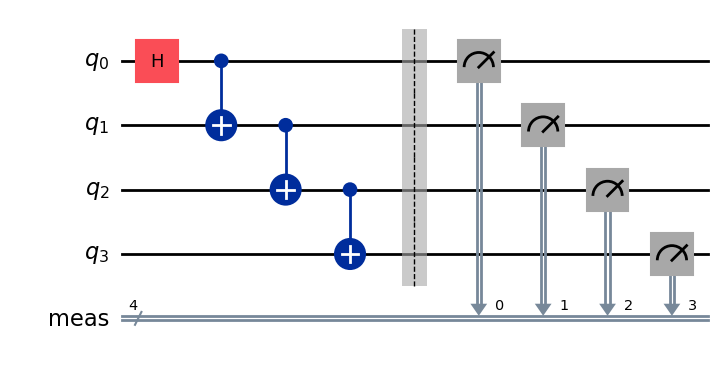

In [33]:
# System Specification
n_qubits = 4
circ = QuantumCircuit(n_qubits)

# Test Circuit
circ.h(0)
for qubit in range(n_qubits - 1):
    circ.cx(qubit, qubit + 1)
circ.measure_all()
circ.draw("mpl")

### Ideal simulation

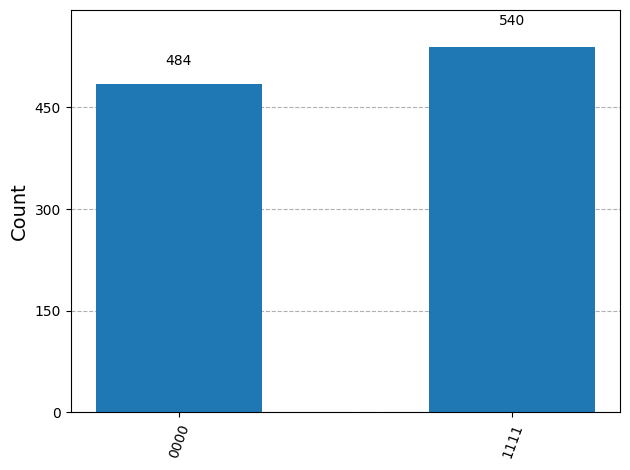

In [34]:
# Ideal simulator and execution
sim_ideal = AerSimulator()
result_ideal = sim_ideal.run(circ).result()
plot_histogram(result_ideal.get_counts(0))

### Noise example 1: Basic bit-flip error noise model
Let's consider a simple toy noise model example common in quantum information theory research:

* When applying a single-qubit gate, flip the state of the qubit with probability `p_gate1`.
* When applying a two-qubit gate, apply single-qubit errors to each qubit.
* When resetting a qubit, reset to 1 instead of 0 with probability `p_reset`.
* When measuring a qubit, flip the state of the qubit with probability `p_meas`.

In [35]:
# Example error probabilities
p_reset = 0.03
p_meas = 0.1
p_gate1 = 0.05

# QuantumError objects
error_reset = pauli_error([("X", p_reset), ("I", 1 - p_reset)])
error_meas = pauli_error([("X", p_meas), ("I", 1 - p_meas)])
error_gate1 = pauli_error([("X", p_gate1), ("I", 1 - p_gate1)])
error_gate2 = error_gate1.tensor(error_gate1)

# Add errors to noise model
noise_bit_flip = NoiseModel()
noise_bit_flip.add_all_qubit_quantum_error(error_reset, "reset")
noise_bit_flip.add_all_qubit_quantum_error(error_meas, "measure")
noise_bit_flip.add_all_qubit_quantum_error(error_gate1, ["u1", "u2", "u3"])
noise_bit_flip.add_all_qubit_quantum_error(error_gate2, ["cx"])

print(noise_bit_flip)

NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx', 'u1', 'u2', 'u3']
  Instructions with noise: ['cx', 'u3', 'measure', 'reset', 'u1', 'u2']
  All-qubits errors: ['reset', 'measure', 'u1', 'u2', 'u3', 'cx']


### Execute the noisy simulation

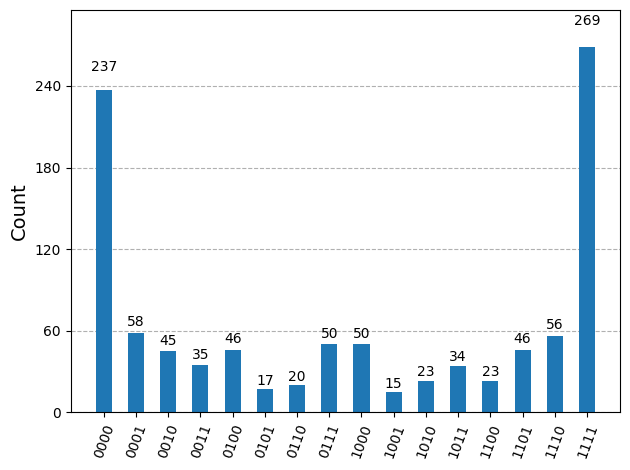

In [38]:
# Create noisy simulator backend
sim_noise = AerSimulator(noise_model=noise_bit_flip)

# Transpile circuit for noisy basis gates
passmanager = generate_preset_pass_manager(
    optimization_level=3, backend=sim_noise
)
circ_tnoise = passmanager.run(circ)

# Run and get counts
result_bit_flip = sim_noise.run(circ_tnoise).result()
counts_bit_flip = result_bit_flip.get_counts(0)

# Plot noisy output
plot_histogram(counts_bit_flip)